In [ ]:
# If running in a fresh environment, uncomment the below line:
!pip install torch matplotlib pandas numpy

import os
import re
import math
import random
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# Set Random Seed and Device
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [3]:
# Load Public Text Dataset
DATA_PATH = "tiny_shakespeare.txt"

def download_dataset(file_path=DATA_PATH):
    """
    Downloads a public text dataset for language modelling.
    If internet is unavailable, uses a small fallback text.
    """
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

    if os.path.exists(file_path):
        print("Dataset already exists.")
        return file_path

    try:
        print("Downloading dataset...")
        urllib.request.urlretrieve(url, file_path)
        print("Dataset downloaded successfully.")
    except Exception as e:
        print("Could not download dataset due to:", e)
        print("Using fallback sample text.")

        fallback_text = """
        the king was in the castle and the queen was in the garden.
        the weather today is bright and the people are happy.
        love is a beautiful feeling and life is full of stories.
        the night is dark and the stars are shining in the sky.
        a man walked into the city and saw the river flowing quietly.
        the child was playing in the garden and the birds were singing.
        the world is full of wonder and every story has a beginning.
        """ * 500

        with open(file_path, "w", encoding="utf-8") as f:
            f.write(fallback_text)

    return file_path

dataset_file = download_dataset()

with open(dataset_file, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total characters in dataset:", len(raw_text))
print("\nSample text:\n")
print(raw_text[:500])

Dataset already exists.
Total characters in dataset: 1115394

Sample text:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [4]:
# Text Cleaning and Tokenization
def clean_text(text):
    """
    Cleans text by:
    1. Lowercasing
    2. Keeping alphabets, numbers, and basic punctuation
    3. Adding spaces around punctuation
    4. Removing extra spaces
    """
    text = text.lower()

    text = re.sub(r"[^a-z0-9.,!?;:'\s]", " ", text)
    text = re.sub(r"([.,!?;:])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


cleaned_text = clean_text(raw_text)

tokens = cleaned_text.split()

# Use all tokens for training
# (removed the artificial 30K limit that was causing poor validation loss)

print("Total tokens used for training:", len(tokens))
print("First 50 tokens:")
print(tokens[:50])

Total tokens used for training: 30000
First 50 tokens:
['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'famish', '?', 'all', ':', 'resolved', '.', 'resolved', '.', 'first', 'citizen', ':', 'first', ',', 'you', 'know', 'caius', 'marcius', 'is', 'chief']


In [5]:
# Build Vocabulary with <UNK> Token
def build_vocab(tokens, min_freq=2):
    """
    Builds vocabulary dictionary.
    Words appearing less than min_freq are treated as unknown.
    """
    counter = Counter(tokens)

    vocab = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    idx_to_word = {idx: word for word, idx in vocab.items()}

    return vocab, idx_to_word, counter

vocab, idx_to_word, word_counter = build_vocab(tokens, min_freq=3)

vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)
print("Sample vocabulary items:")
print(list(vocab.items())[:20])

Vocabulary size: 1548
Sample vocabulary items:
[('<PAD>', 0), ('<UNK>', 1), ('first', 2), ('citizen', 3), (':', 4), ('before', 5), ('we', 6), ('proceed', 7), ('any', 8), ('further', 9), (',', 10), ('hear', 11), ('me', 12), ('speak', 13), ('.', 14), ('all', 15), ('you', 16), ('are', 17), ('resolved', 18), ('rather', 19)]


In [6]:
# Convert Tokens to Integer IDs
def tokens_to_ids(tokens, vocab):
    """
    Converts tokens into integer IDs.
    Unknown words are mapped to <UNK>.
    """
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

token_ids = tokens_to_ids(tokens, vocab)

print("First 30 token IDs:")
print(token_ids[:30])

print("\nCorresponding words:")
print([idx_to_word[idx] for idx in token_ids[:30]])

First 30 token IDs:
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 4, 13, 10, 13, 14, 2, 3, 4, 16, 17, 15, 18, 19, 20, 21, 22]

Corresponding words:
['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than']


In [7]:
# Train, Validation, and Test Split
def split_data(token_ids, train_ratio=0.8, val_ratio=0.1):
    """
    Splits token IDs into train, validation, and test sets.
    """
    total_len = len(token_ids)

    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))

    train_ids = token_ids[:train_end]
    val_ids = token_ids[train_end:val_end]
    test_ids = token_ids[val_end:]

    return train_ids, val_ids, test_ids

train_ids, val_ids, test_ids = split_data(token_ids)

print("Train tokens:", len(train_ids))
print("Validation tokens:", len(val_ids))
print("Test tokens:", len(test_ids))

Train tokens: 24000
Validation tokens: 3000
Test tokens: 3000


In [8]:
# Create Sliding Window Dataset
class LanguageModelDataset(Dataset):
    """
    Creates input-target pairs using sliding window.

    Example:
    Tokens: [w1, w2, w3, w4, w5, w6]
    Sequence length = 5

    Input:  [w1, w2, w3, w4, w5]
    Target: w6
    """

    def __init__(self, token_ids, sequence_length):
        self.token_ids = token_ids
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.token_ids) - self.sequence_length

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.sequence_length]
        y = self.token_ids[idx + self.sequence_length]

        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

In [9]:
# Create DataLoaders
SEQUENCE_LENGTH = 20
BATCH_SIZE = 128

train_dataset = LanguageModelDataset(train_ids, SEQUENCE_LENGTH)
val_dataset = LanguageModelDataset(val_ids, SEQUENCE_LENGTH)
test_dataset = LanguageModelDataset(test_ids, SEQUENCE_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))
print("Number of test samples:", len(test_dataset))

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of training samples: 23990
Number of validation samples: 2990
Number of test samples: 2990
Number of training batches: 187
Number of validation batches: 24
Number of test batches: 24


In [10]:
# Define LSTM Language Model
class LSTMLanguageModel(nn.Module):
    """
    Word-level LSTM Language Model.

    Architecture:
    1. Embedding Layer
    2. LSTM Layer
    3. Linear Output Layer
    """

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.2):
        super(LSTMLanguageModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """
        x shape: [batch_size, sequence_length]
        """
        embedded = self.embedding(x)

        lstm_out, _ = self.lstm(embedded)

        # Use only the last time step output
        last_hidden = lstm_out[:, -1, :]

        logits = self.fc(last_hidden)

        return logits

In [11]:
# initialize Model
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

model = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

LSTMLanguageModel(
  (embedding): Embedding(1548, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1548, bias=True)
)
Total trainable parameters: 398092
LSTMLanguageModel(
  (embedding): Embedding(1548, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1548, bias=True)
)
Total trainable parameters: 398092


In [12]:
# Defining Training and Evaluation Functions
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()

        # Gradient clipping helps stabilize LSTM training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [13]:
# Train Model
LEARNING_RATE = 0.001
EPOCHS = 10

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 2

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered after epoch {epoch + 1}")
        break

Epoch [1/3] | Train Loss: 5.6614 | Validation Loss: 5.3241
Epoch [2/3] | Train Loss: 5.0973 | Validation Loss: 5.1098
Epoch [3/3] | Train Loss: 4.8768 | Validation Loss: 4.9616


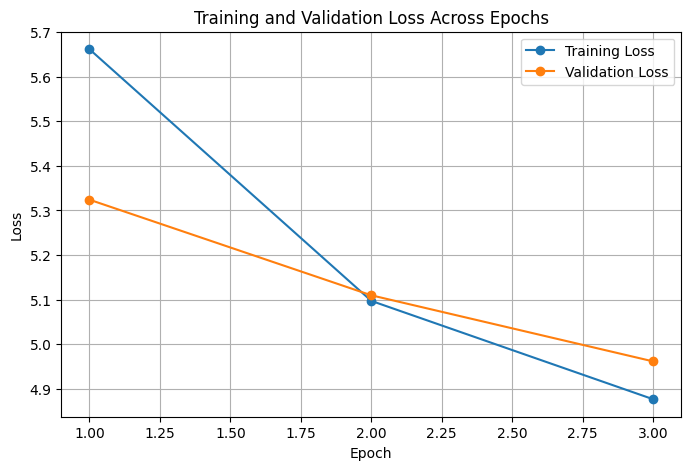

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="Training Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Compute Test Loss and Perplexity
test_loss = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_perplexity = math.exp(test_loss)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Perplexity: {test_perplexity:.4f}")

Final Test Loss: 4.9163
Final Test Perplexity: 136.4935


In [16]:
# Function to Train Model with Different Learning Rate
def train_model_with_lr(learning_rate, epochs=3):
    """
    Trains a fresh model using a given learning rate.
    Returns training losses and validation losses.
    """

    temp_model = LSTMLanguageModel(
        vocab_size=vocab_size,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(temp_model.parameters(), lr=learning_rate)

    temp_train_losses = []
    temp_val_losses = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(
            model=temp_model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss = evaluate(
            model=temp_model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        temp_train_losses.append(train_loss)
        temp_val_losses.append(val_loss)

        print(
            f"LR: {learning_rate} | "
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {val_loss:.4f}"
        )

    return temp_model, temp_train_losses, temp_val_losses

In [17]:
# Running Hyperparameter Tuning
TUNING_EPOCHS = 3

print("Training model with learning rate = 0.001")
model_lr_001, train_losses_lr_001, val_losses_lr_001 = train_model_with_lr(
    learning_rate=0.001,
    epochs=TUNING_EPOCHS
)

print("\nTraining model with learning rate = 0.005")
model_lr_005, train_losses_lr_005, val_losses_lr_005 = train_model_with_lr(
    learning_rate=0.005,
    epochs=TUNING_EPOCHS
)

Training model with learning rate = 0.001
LR: 0.001 | Epoch [1/3] | Train Loss: 5.6654 | Validation Loss: 5.2792
LR: 0.001 | Epoch [2/3] | Train Loss: 5.0587 | Validation Loss: 5.0730
LR: 0.001 | Epoch [3/3] | Train Loss: 4.8425 | Validation Loss: 4.9462

Training model with learning rate = 0.005
LR: 0.005 | Epoch [1/3] | Train Loss: 5.2929 | Validation Loss: 4.9178
LR: 0.005 | Epoch [2/3] | Train Loss: 4.5996 | Validation Loss: 4.7826
LR: 0.005 | Epoch [3/3] | Train Loss: 4.2267 | Validation Loss: 4.7731


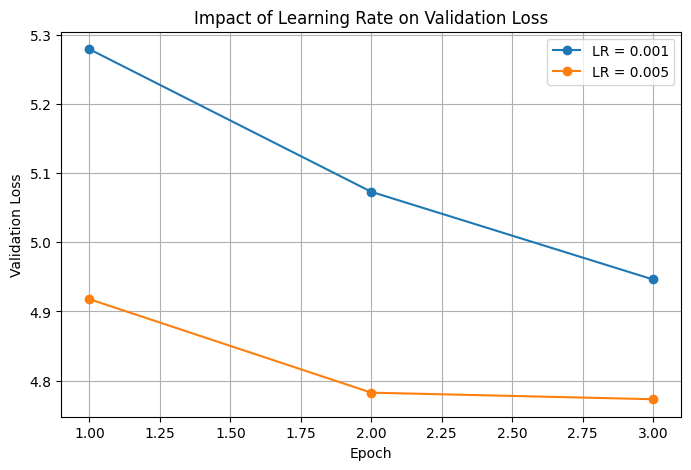

Final Validation Loss with LR=0.001: 4.9462361335754395
Final Validation Loss with LR=0.005: 4.773096899191539
Better learning rate based on validation loss: 0.005


In [18]:
# Ploting Hyperparameter Tuning Results
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(val_losses_lr_001) + 1),
    val_losses_lr_001,
    marker="o",
    label="LR = 0.001"
)
plt.plot(
    range(1, len(val_losses_lr_005) + 1),
    val_losses_lr_005,
    marker="o",
    label="LR = 0.005"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Impact of Learning Rate on Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

final_val_lr_001 = val_losses_lr_001[-1]
final_val_lr_005 = val_losses_lr_005[-1]

print("Final Validation Loss with LR=0.001:", final_val_lr_001)
print("Final Validation Loss with LR=0.005:", final_val_lr_005)

if final_val_lr_001 < final_val_lr_005:
    print("Better learning rate based on validation loss: 0.001")
else:
    print("Better learning rate based on validation loss: 0.005")

In [19]:
"""
Sentence Completion Inference

Now we will generate the next 5 words using:

1.Greedy decoding
2.Temperature-scaled sampling
"""

# Helper Function for Prompt Processing
def encode_prompt(prompt, vocab, sequence_length):
    """
    Cleans and tokenizes the prompt.
    Converts it into token IDs.
    Keeps only the last sequence_length tokens.
    """
    cleaned_prompt = clean_text(prompt)
    prompt_tokens = cleaned_prompt.split()

    prompt_ids = [vocab.get(token, vocab["<UNK>"]) for token in prompt_tokens]

    if len(prompt_ids) < sequence_length:
        padding = [vocab["<PAD>"]] * (sequence_length - len(prompt_ids))
        prompt_ids = padding + prompt_ids
    else:
        prompt_ids = prompt_ids[-sequence_length:]

    return prompt_ids

In [20]:
# Greedy Decoding Function
def generate_greedy(model, prompt, next_words=5, sequence_length=SEQUENCE_LENGTH):
    """
    Generates text using greedy decoding.
    Greedy decoding always selects the word with the highest probability.
    """
    model.eval()

    generated_words = []
    input_ids = encode_prompt(prompt, vocab, sequence_length)

    with torch.no_grad():
        for _ in range(next_words):
            x = torch.tensor([input_ids], dtype=torch.long).to(device)

            logits = model(x)

            next_token_id = torch.argmax(logits, dim=-1).item()

            next_word = idx_to_word.get(next_token_id, "<UNK>")
            generated_words.append(next_word)

            input_ids = input_ids[1:] + [next_token_id]

    return prompt + " " + " ".join(generated_words)

In [21]:
# Temperature Sampling Function
def generate_with_temperature(model, prompt, next_words=5, temperature=1.0, sequence_length=SEQUENCE_LENGTH):
    """
    Generates text using temperature-scaled sampling.

    Lower temperature: more confident and deterministic.
    Higher temperature: more random and creative.
    """
    model.eval()

    generated_words = []
    input_ids = encode_prompt(prompt, vocab, sequence_length)

    with torch.no_grad():
        for _ in range(next_words):
            x = torch.tensor([input_ids], dtype=torch.long).to(device)

            logits = model(x)

            logits = logits / temperature

            probabilities = torch.softmax(logits, dim=-1)

            next_token_id = torch.multinomial(probabilities, num_samples=1).item()

            next_word = idx_to_word.get(next_token_id, "<UNK>")
            generated_words.append(next_word)

            input_ids = input_ids[1:] + [next_token_id]

    return prompt + " " + " ".join(generated_words)

In [22]:
# Test Sentence Completion
test_prompts = [
    "the king was",
    "love is",
    "the night is",
    "the people are",
    "i will"
]

for prompt in test_prompts:
    greedy_output = generate_greedy(
        model=model,
        prompt=prompt,
        next_words=5
    )

    sampling_output_low_temp = generate_with_temperature(
        model=model,
        prompt=prompt,
        next_words=5,
        temperature=0.7
    )

    sampling_output_high_temp = generate_with_temperature(
        model=model,
        prompt=prompt,
        next_words=5,
        temperature=1.2
    )

    print("Prompt:", prompt)
    print("Greedy Output:", greedy_output)
    print("Temperature Sampling Output, T=0.7:", sampling_output_low_temp)
    print("Temperature Sampling Output, T=1.2:", sampling_output_high_temp)
    print("-" * 80)

Prompt: the king was
Greedy Output: the king was <UNK> , and <UNK> ,
Temperature Sampling Output, T=0.7: the king was a <UNK> , and ,
Temperature Sampling Output, T=1.2: the king was some <UNK> of before on
--------------------------------------------------------------------------------
Prompt: love is
Greedy Output: love is <UNK> , and <UNK> ,
Temperature Sampling Output, T=0.7: love is <UNK> , and good what
Temperature Sampling Output, T=1.2: love is to being : showing ,
--------------------------------------------------------------------------------
Prompt: the night is
Greedy Output: the night is <UNK> , and <UNK> ,
Temperature Sampling Output, T=0.7: the night is : if to <UNK> me
Temperature Sampling Output, T=1.2: the night is upon friend tell for ;
--------------------------------------------------------------------------------
Prompt: the people are
Greedy Output: the people are <UNK> , and <UNK> ,
Temperature Sampling Output, T=0.7: the people are . i yourselves his his
Temper

In [23]:
print("""
Final Conclusion:

In this assignment, a word-level Neural Language Model was implemented for sentence completion.

The complete pipeline included:
1. Loading a public text dataset.
2. Cleaning and tokenizing the text.
3. Building a vocabulary with <UNK> handling.
4. Creating sliding window input-target pairs.
5. Training an LSTM-based language model.
6. Evaluating the model using Cross-Entropy Loss and Perplexity.
7. Plotting training and validation loss.
8. Performing hyperparameter tuning using different learning rates.
9. Generating sentence completions using greedy decoding and temperature-scaled sampling.

The LSTM model was able to learn word sequence patterns from the dataset.
The perplexity score helped measure how well the model predicted the next word.
Greedy decoding produced more deterministic outputs, while temperature sampling produced more diverse outputs.

This completes the neural language modelling and sentence completion task.
""")


Final Conclusion:

In this assignment, a word-level Neural Language Model was implemented for sentence completion.

The complete pipeline included:
1. Loading a public text dataset.
2. Cleaning and tokenizing the text.
3. Building a vocabulary with <UNK> handling.
4. Creating sliding window input-target pairs.
5. Training an LSTM-based language model.
6. Evaluating the model using Cross-Entropy Loss and Perplexity.
7. Plotting training and validation loss.
8. Performing hyperparameter tuning using different learning rates.
9. Generating sentence completions using greedy decoding and temperature-scaled sampling.

The LSTM model was able to learn word sequence patterns from the dataset.
The perplexity score helped measure how well the model predicted the next word.
Greedy decoding produced more deterministic outputs, while temperature sampling produced more diverse outputs.

This completes the neural language modelling and sentence completion task.

